The following code takes the daily grids created by machine learning, couples them with the closest points from the CMEMS L4 product and reshuffle both into time series for each lat-lon couple, named "time_series_data"

/tmp/ipykernel_27067/3226191548.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_data[(lat, lon, 'csv')] = time_series_data[(lat, lon)]
/tmp/ipykernel_27067/3226191548.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_data[(lat, lon, 'cmems')] = cmems_time_series
/tmp/ipykernel_27067/3226191548.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1

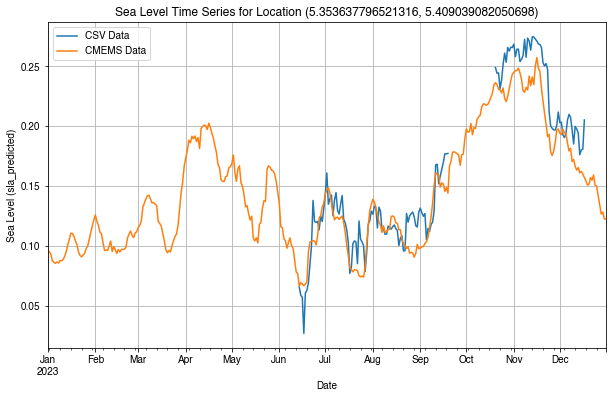

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np
from netCDF4 import Dataset
from scipy.spatial import cKDTree

# Directory containing the CSV files without extensions
csv_directory = '/DGFI8/H/work_marcello/giussani_machinelearning_data/WEST_AFRICA_ML_GRID_2023_COASTAL'

# Directory containing the NetCDF file from CMEMS
# downloaded through https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L4_NRT_008_046/download
nc_directory = '/DGFI8/H/work_marcello/giussani_machinelearning_data/SEALEVEL_GLO_PHY_L4_REP_OBSERVATIONS_008_047'
nc_file = 'cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_1718195200333.nc'

# Initialize an empty DataFrame to store all data
all_data = pd.DataFrame()

# Loop through each file and aggregate the data
for filename in sorted(os.listdir(csv_directory)):
    if filename.startswith('WEST_AFRICA_ML_GRID_2023_'):
        date_str = filename.split('_')[-3] + '_' + filename.split('_')[-2] + '_' + filename.split('_')[-1]
        date = pd.to_datetime(date_str, format='%Y_%m_%d')
        file_path = os.path.join(csv_directory, filename)
        df = pd.read_csv(file_path)
        df['date'] = date
        all_data = pd.concat([all_data, df], ignore_index=True)

# Pivot the data to have dates as the index and (lat, lon) as columns
time_series_data = all_data.pivot_table(index='date', columns=['lat', 'lon'], values='sla_predicted')

# Load the CMEMS NetCDF data
nc_path = os.path.join(nc_directory, nc_file)
nc_data = Dataset(nc_path)

# Extract lat, lon, and sla from the NetCDF file
cmems_lat = nc_data.variables['latitude'][:]
cmems_lon = nc_data.variables['longitude'][:]
cmems_sla = nc_data.variables['sla'][:]

# Create a meshgrid for the lat and lon values
cmems_lon_grid, cmems_lat_grid = np.meshgrid(cmems_lon, cmems_lat)

# Flatten the grids to create a list of lat-lon pairs
cmems_coords = np.column_stack((cmems_lat_grid.ravel(), cmems_lon_grid.ravel()))

# Build a KDTree for fast lookup of nearest neighbors
tree = cKDTree(cmems_coords)

# Helper function to find the closest non-NaN location
def find_closest_non_nan(lat, lon, cmems_sla, tree, cmems_coords, lat_grid, lon_grid):
    distances, indices = tree.query([lat, lon], k=100)  # check the 100 closest points
    for index in indices:
        closest_lat, closest_lon = cmems_coords[index]
        i = np.where(lat_grid == closest_lat)[0][0]
        j = np.where(lon_grid == closest_lon)[0][0]
        if not np.isnan(cmems_sla[:, i, j]).all():  # Ensure there is at least one non-NaN value
            return closest_lat, closest_lon, cmems_sla[:, i, j]
    return None, None, None

# Create a DataFrame to store the combined time series data
combined_data = pd.DataFrame(index=time_series_data.index)

# Loop through each lat-lon location in the time series data
for lat, lon in time_series_data.columns:
    # Find the nearest CMEMS lat-lon location with non-NaN SLA values
    closest_lat, closest_lon, cmems_time_series = find_closest_non_nan(lat, lon, cmems_sla, tree, cmems_coords, cmems_lat, cmems_lon)
    
    if closest_lat is not None and closest_lon is not None:
        # Add the CMEMS time series to the combined data
        combined_data[(lat, lon, 'csv')] = time_series_data[(lat, lon)]
        combined_data[(lat, lon, 'cmems')] = cmems_time_series

# Select a random lat-lon location
random_location = random.choice(time_series_data.columns)

# Plot the time series for the selected location
plt.figure(figsize=(10, 6))
combined_data[(random_location[0], random_location[1], 'csv')].plot(label='CSV Data')
combined_data[(random_location[0], random_location[1], 'cmems')].plot(label='CMEMS Data')
plt.title(f'Sea Level Time Series for Location {random_location}')
plt.xlabel('Date')
plt.ylabel('Sea Level (sla_predicted)')
plt.legend()
plt.grid(True)
plt.show()


The following code creates an Hovmoller diagram based on latitude

/tmp/ipykernel_27067/3316292302.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_data[(lat, lon, 'csv')] = time_series_data[(lat, lon)]
/tmp/ipykernel_27067/3316292302.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_data[(lat, lon, 'cmems')] = cmems_time_series
/tmp/ipykernel_27067/3316292302.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1

/tmp/ipykernel_27067/3316292302.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  latitude_data[(lat, 'csv')] = csv_series.iloc[:, 0]
/tmp/ipykernel_27067/3316292302.py:90: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  latitude_data[(lat, 'cmems')] = cmems_series.iloc[:, 0]
/tmp/ipykernel_27067/3316292302.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. 

/tmp/ipykernel_27067/3316292302.py:90: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  latitude_data[(lat, 'cmems')] = cmems_series.iloc[:, 0]
/tmp/ipykernel_27067/3316292302.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  latitude_data[(lat, 'csv')] = csv_series.iloc[:, 0]
/tmp/ipykernel_27067/3316292302.py:90: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. 

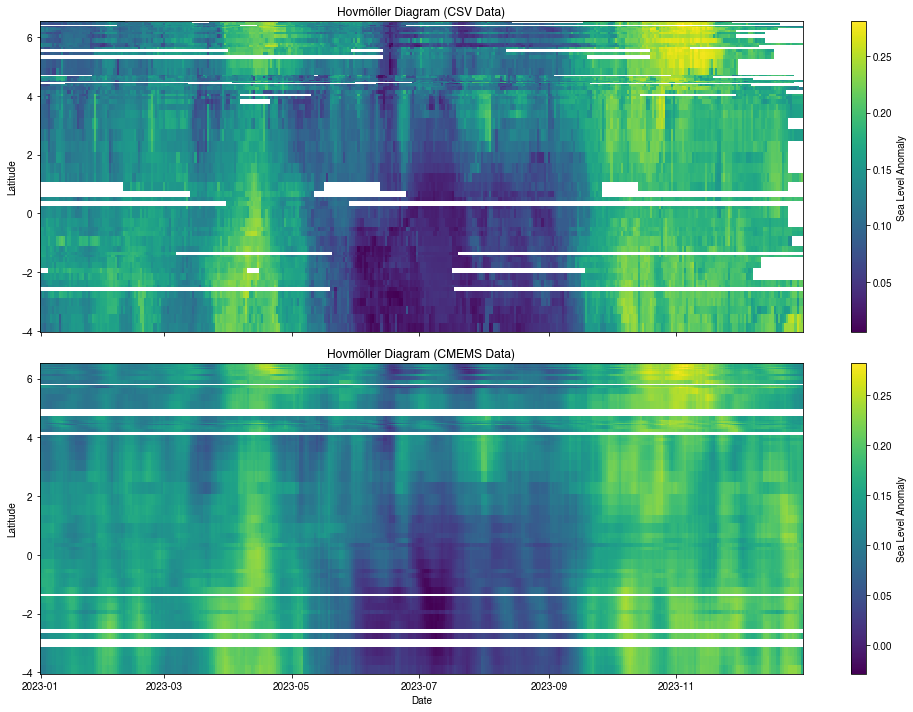

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np
from netCDF4 import Dataset
from scipy.spatial import cKDTree

# Directory containing the CSV files without extensions
csv_directory = '/DGFI8/H/work_marcello/giussani_machinelearning_data/WEST_AFRICA_ML_GRID_2023_COASTAL'

# Directory containing the NetCDF file from CMEMS
# downloaded through https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L4_NRT_008_046/download
nc_directory = '/DGFI8/H/work_marcello/giussani_machinelearning_data/SEALEVEL_GLO_PHY_L4_REP_OBSERVATIONS_008_047'
nc_file = 'cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_1718195200333.nc'

# Initialize an empty DataFrame to store all data
all_data = pd.DataFrame()

# Loop through each file and aggregate the data
for filename in sorted(os.listdir(csv_directory)):
    if filename.startswith('WEST_AFRICA_ML_GRID_2023_'):
        date_str = filename.split('_')[-3] + '_' + filename.split('_')[-2] + '_' + filename.split('_')[-1]
        date = pd.to_datetime(date_str, format='%Y_%m_%d')
        file_path = os.path.join(csv_directory, filename)
        df = pd.read_csv(file_path)
        df['date'] = date
        all_data = pd.concat([all_data, df], ignore_index=True)

# Pivot the data to have dates as the index and (lat, lon) as columns
time_series_data = all_data.pivot_table(index='date', columns=['lat', 'lon'], values='sla_predicted')

# Load the CMEMS NetCDF data
nc_path = os.path.join(nc_directory, nc_file)
nc_data = Dataset(nc_path)

# Extract lat, lon, and sla from the NetCDF file
cmems_lat = nc_data.variables['latitude'][:]
cmems_lon = nc_data.variables['longitude'][:]
cmems_sla = nc_data.variables['sla'][:]

# Create a meshgrid for the lat and lon values
cmems_lon_grid, cmems_lat_grid = np.meshgrid(cmems_lon, cmems_lat)

# Flatten the grids to create a list of lat-lon pairs
cmems_coords = np.column_stack((cmems_lat_grid.ravel(), cmems_lon_grid.ravel()))

# Build a KDTree for fast lookup of nearest neighbors
tree = cKDTree(cmems_coords)

# Helper function to find the closest non-NaN location
def find_closest_non_nan(lat, lon, cmems_sla, tree, cmems_coords, lat_grid, lon_grid):
    distances, indices = tree.query([lat, lon], k=100)  # check the 100 closest points
    for index in indices:
        closest_lat, closest_lon = cmems_coords[index]
        i = np.where(lat_grid == closest_lat)[0][0]
        j = np.where(lon_grid == closest_lon)[0][0]
        if not np.isnan(cmems_sla[:, i, j]).all():  # Ensure there is at least one non-NaN value
            return closest_lat, closest_lon, cmems_sla[:, i, j]
    return None, None, None

# Create a DataFrame to store the combined time series data with (lat, lon, source) as columns
combined_data = pd.DataFrame(index=time_series_data.index)

# Loop through each lat-lon location in the time series data
for lat, lon in time_series_data.columns:
    # Find the nearest CMEMS lat-lon location with non-NaN SLA values
    closest_lat, closest_lon, cmems_time_series = find_closest_non_nan(lat, lon, cmems_sla, tree, cmems_coords, cmems_lat, cmems_lon)
    
    if closest_lat is not None and closest_lon is not None:
        # Add the CMEMS time series to the combined data
        combined_data[(lat, lon, 'csv')] = time_series_data[(lat, lon)]
        combined_data[(lat, lon, 'cmems')] = cmems_time_series

# Ensure columns are MultiIndex for easier manipulation
combined_data.columns = pd.MultiIndex.from_tuples(combined_data.columns)

# Create a DataFrame to store latitude-based time series data
latitude_data = pd.DataFrame(index=combined_data.index)

# Loop through each unique latitude
for lat in combined_data.columns.get_level_values(0).unique():
    # Extract the time series for the latitude from both csv and cmems data
    csv_series = combined_data.xs(key=lat, axis=1, level=0).xs('csv', axis=1, level=1)
    cmems_series = combined_data.xs(key=lat, axis=1, level=0).xs('cmems', axis=1, level=1)
    
    if not csv_series.empty and not cmems_series.empty:
        # Since there's only one longitude per latitude, take the first column
        latitude_data[(lat, 'csv')] = csv_series.iloc[:, 0]
        latitude_data[(lat, 'cmems')] = cmems_series.iloc[:, 0]

# Ensure columns are MultiIndex for easier manipulation
latitude_data.columns = pd.MultiIndex.from_tuples(latitude_data.columns)

# Generate Hovmöller diagram based on latitude
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Hovmöller diagram for CSV data
c1 = ax[0].pcolormesh(latitude_data.index, latitude_data.columns.get_level_values(0).unique(), latitude_data.xs('csv', axis=1, level=1).T, shading='auto', cmap='viridis')
ax[0].set_title('Hovmöller Diagram (CSV Data)')
ax[0].set_ylabel('Latitude')
fig.colorbar(c1, ax=ax[0], orientation='vertical', label='Sea Level Anomaly')

# Hovmöller diagram for CMEMS data
c2 = ax[1].pcolormesh(latitude_data.index, latitude_data.columns.get_level_values(0).unique(), latitude_data.xs('cmems', axis=1, level=1).T, shading='auto', cmap='viridis')
ax[1].set_title('Hovmöller Diagram (CMEMS Data)')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Latitude')
fig.colorbar(c2, ax=ax[1], orientation='vertical', label='Sea Level Anomaly')

plt.tight_layout()
plt.show()


In [3]:
lons = []
lats = []

for k in range(len(time_series_data.T.index)):
    
    lons.append(time_series_data.T.index[k][1])
    lats.append(time_series_data.T.index[k][0])

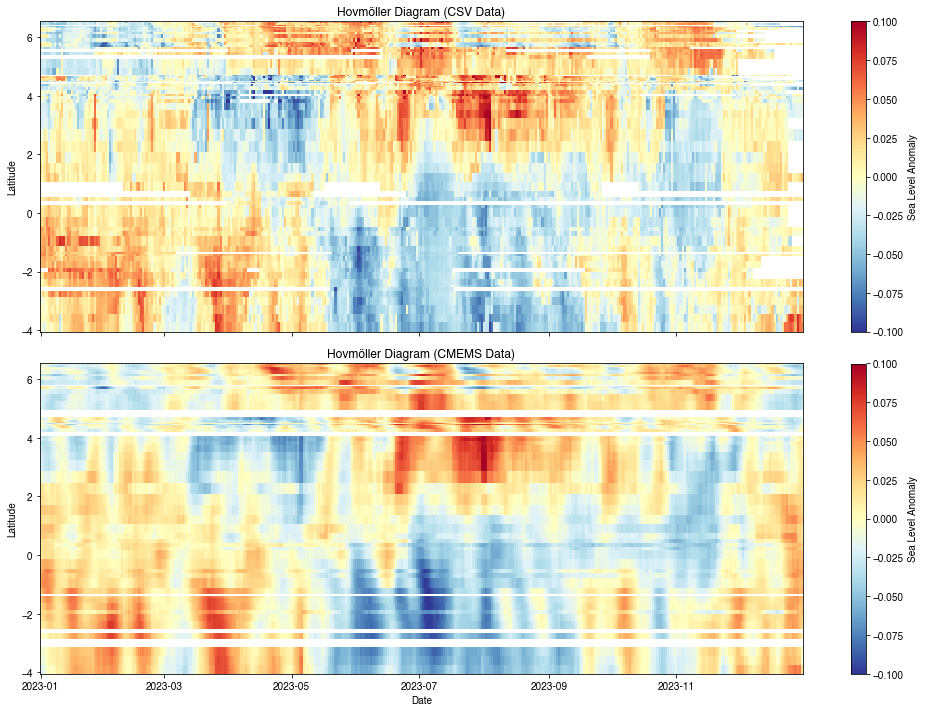

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

c1 = ax[0].pcolormesh(latitude_data.index, latitude_data.columns.get_level_values(0).unique(), 
                      latitude_data.xs('csv', axis=1, level=1).T-np.nanmean(latitude_data.xs('csv', axis=1, level=1).T,axis=0), 
                      shading='auto', cmap='RdYlBu_r',
                     vmax=.1,vmin=-.1)
ax[0].set_title('Hovmöller Diagram (CSV Data)')
ax[0].set_ylabel('Latitude')
fig.colorbar(c1, ax=ax[0], orientation='vertical', label='Sea Level Anomaly')

# Hovmöller diagram for CMEMS data
c2 = ax[1].pcolormesh(latitude_data.index, latitude_data.columns.get_level_values(0).unique(), 
                      latitude_data.xs('cmems', axis=1, level=1).T-np.nanmean(latitude_data.xs('cmems', axis=1, level=1).T,axis=0), 
                      shading='auto', cmap='RdYlBu_r',
                     vmax=.1,vmin=-.1)
ax[1].set_title('Hovmöller Diagram (CMEMS Data)')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Latitude')
fig.colorbar(c2, ax=ax[1], orientation='vertical', label='Sea Level Anomaly')

plt.tight_layout()
plt.show()


    # Mikes stuff for Marcello

In [8]:
import xarray as xr
import pygmt

In [83]:
nc = xr.open_dataset("/DGFI8/H/work_mike/SWOT_Data/SWOT_Franck_3.nc") # gridded SWOT data

NC = nc.ssh[0]

lons = np.array(lons)
lats = np.array(lats)

In [100]:
marcello = np.zeros((len(nc.ssh),len(lons)))

for m in range(len(nc.ssh)):
    
    nlon = np.ravel(nc.lon)
    nlat = np.ravel(nc.lat)
    nssh = np.ravel(nc.ssh[m])

    md = pygmt.xyz2grd(x=nlon,y=nlat,z=nssh,region='8/13/-20/5',spacing=0.02)

    md = md.interpolate_na(dim="x", method="nearest", fill_value="extrapolate")
    md = md.interpolate_na(dim="y", method="nearest", fill_value="extrapolate")

#     ind = np.where((lons<15)&(lons>0)&(lats<5)&(lats>-20))[0]
    pas = md.sel(x=lons,y=lats,method='nearest')
    mas = np.nanmean(pas.data,axis=1)

    marcello[m] = mas

/tmp/ipykernel_27067/1089186730.py:16: RuntimeWarning: Mean of empty slice
  mas = np.nanmean(pas.data,axis=1)


Text(0.5, 1.0, 'Hovmöller Diagram (SWOT Cal/Val Data)')

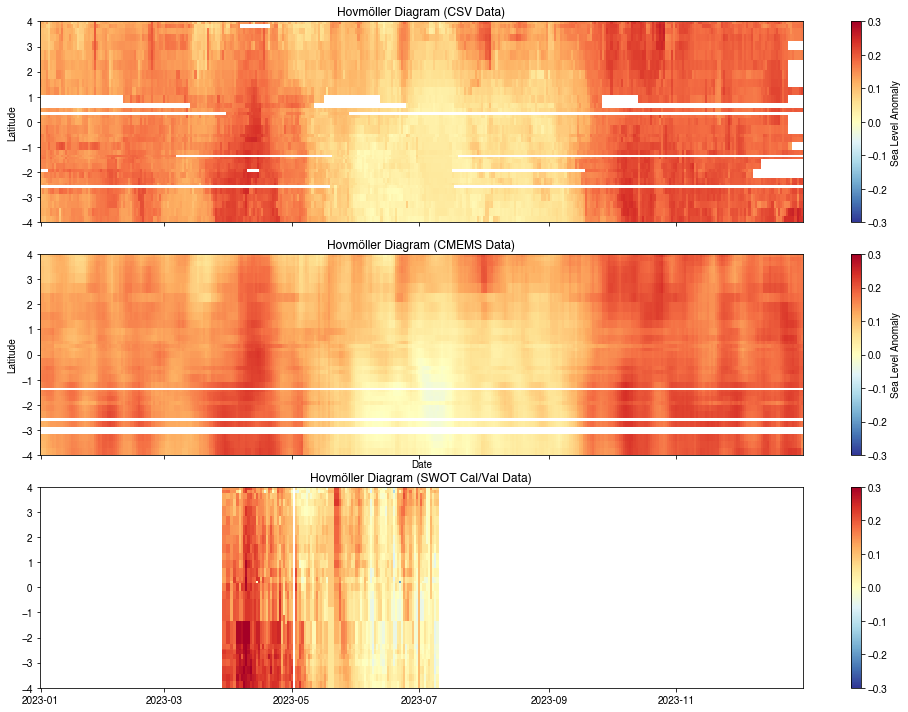

In [104]:
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

vmax = .3
vmin = -vmax
c1 = ax[0].pcolormesh(latitude_data.index, latitude_data.columns.get_level_values(0).unique(), 
                      latitude_data.xs('csv', axis=1, level=1).T,#-np.nanmean(latitude_data.xs('csv', axis=1, level=1).T,axis=0), 
                      shading='auto', cmap='RdYlBu_r',
                     vmax=vmax,vmin=vmin)
ax[0].set_title('Hovmöller Diagram (CSV Data)')
ax[0].set_ylabel('Latitude')
fig.colorbar(c1, ax=ax[0], orientation='vertical', label='Sea Level Anomaly')

# Hovmöller diagram for CMEMS data
c2 = ax[1].pcolormesh(latitude_data.index, latitude_data.columns.get_level_values(0).unique(), 
                      latitude_data.xs('cmems', axis=1, level=1).T,#-np.nanmean(latitude_data.xs('cmems', axis=1, level=1).T,axis=0), 
                      shading='auto', cmap='RdYlBu_r',
                     vmax=vmax,vmin=vmin)

ax[1].set_title('Hovmöller Diagram (CMEMS Data)')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Latitude')
fig.colorbar(c2, ax=ax[1], orientation='vertical', label='Sea Level Anomaly')

plt.tight_layout()

cb = ax[2].pcolormesh(nc.t,lats,marcello.T,vmax=vmax,vmin=vmin
                    ,cmap=plt.cm.RdYlBu_r)
ax[0].set_ylim(-4,4)
ax[1].set_ylim(-4,4)
ax[2].set_ylim(-4,4)
plt.colorbar(cb)
ax[2].set_title('Hovmöller Diagram (SWOT Cal/Val Data)')


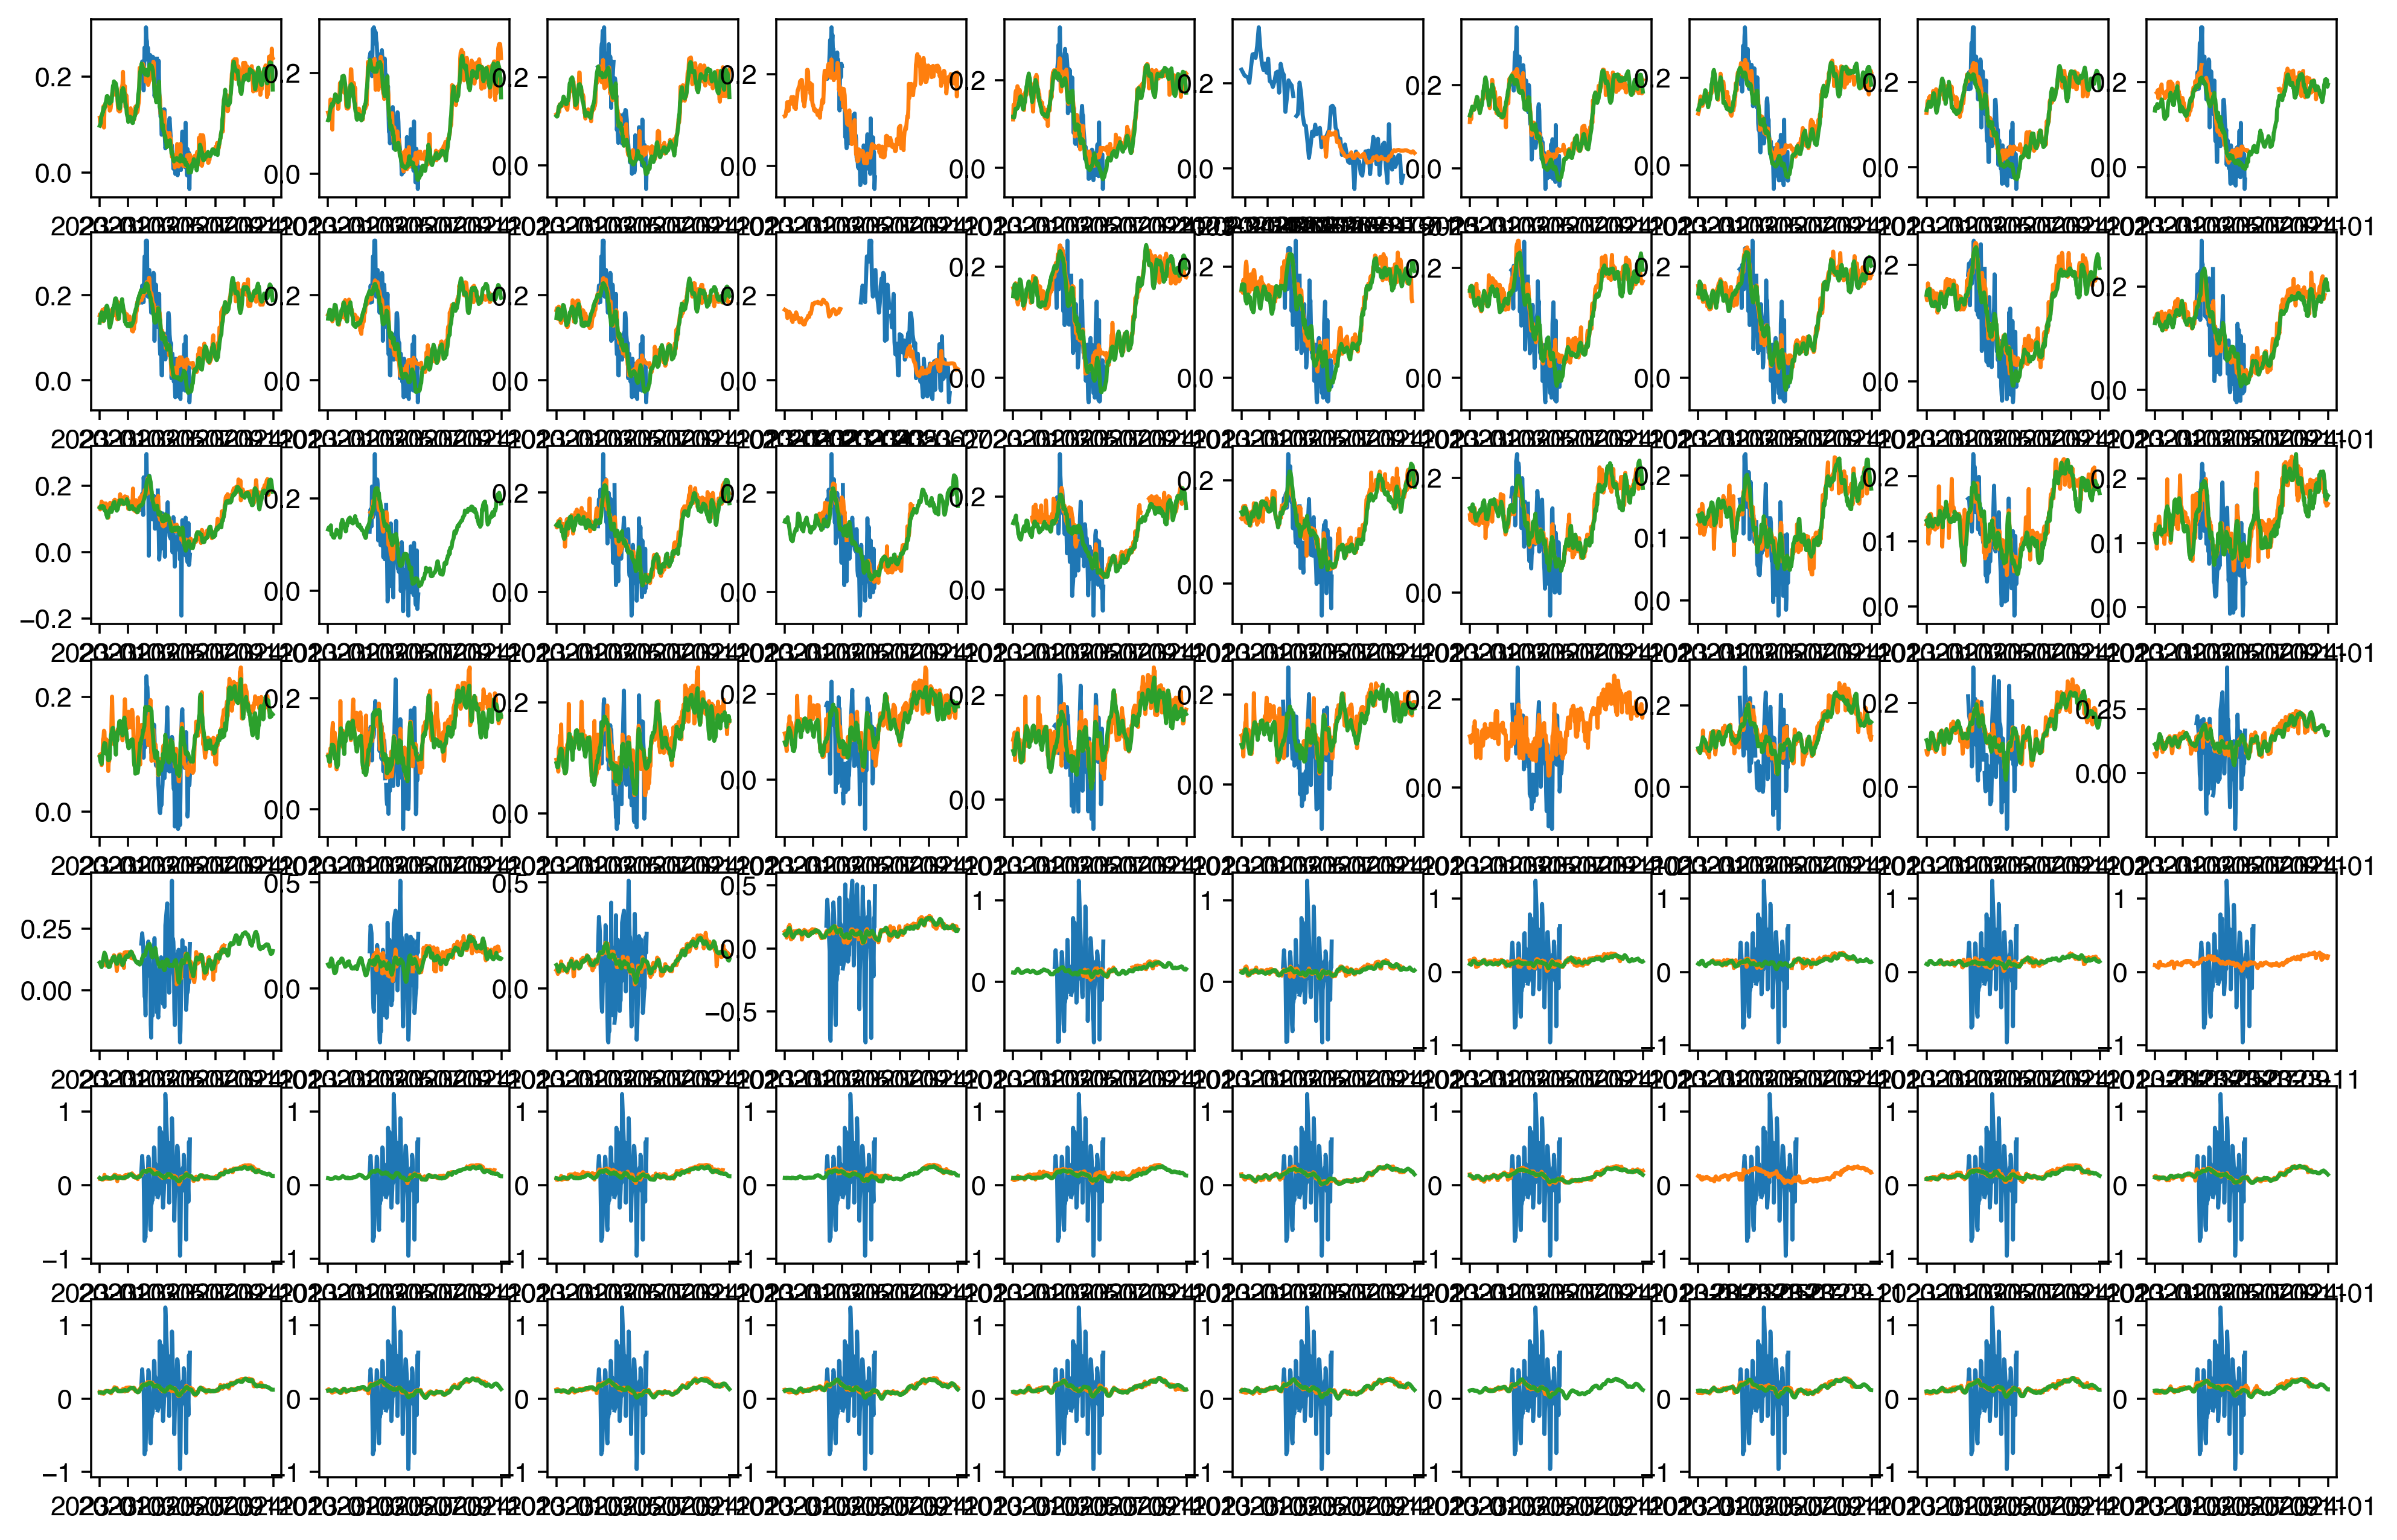

In [150]:
df = latitude_data.xs('cmems', axis=1, level=1).T
df['index_col'] = df.index
df = df.reset_index(drop=True)

lk = latitude_data.xs('csv', axis=1, level=1).T
lk['index_col'] = lk.index
lk = lk.reset_index(drop=True)

plt.figure(figsize=(15,10),dpi=320)

for l in range(70):
    plt.subplot(7,10,l+1)
    plt.plot(nc.t,marcello.T[l])
    plt.plot(lk.T.index[:-1],np.array(lk.T[l])[:-1])
    plt.plot(df.T.index[:-1],np.array(df.T[l])[:-1])

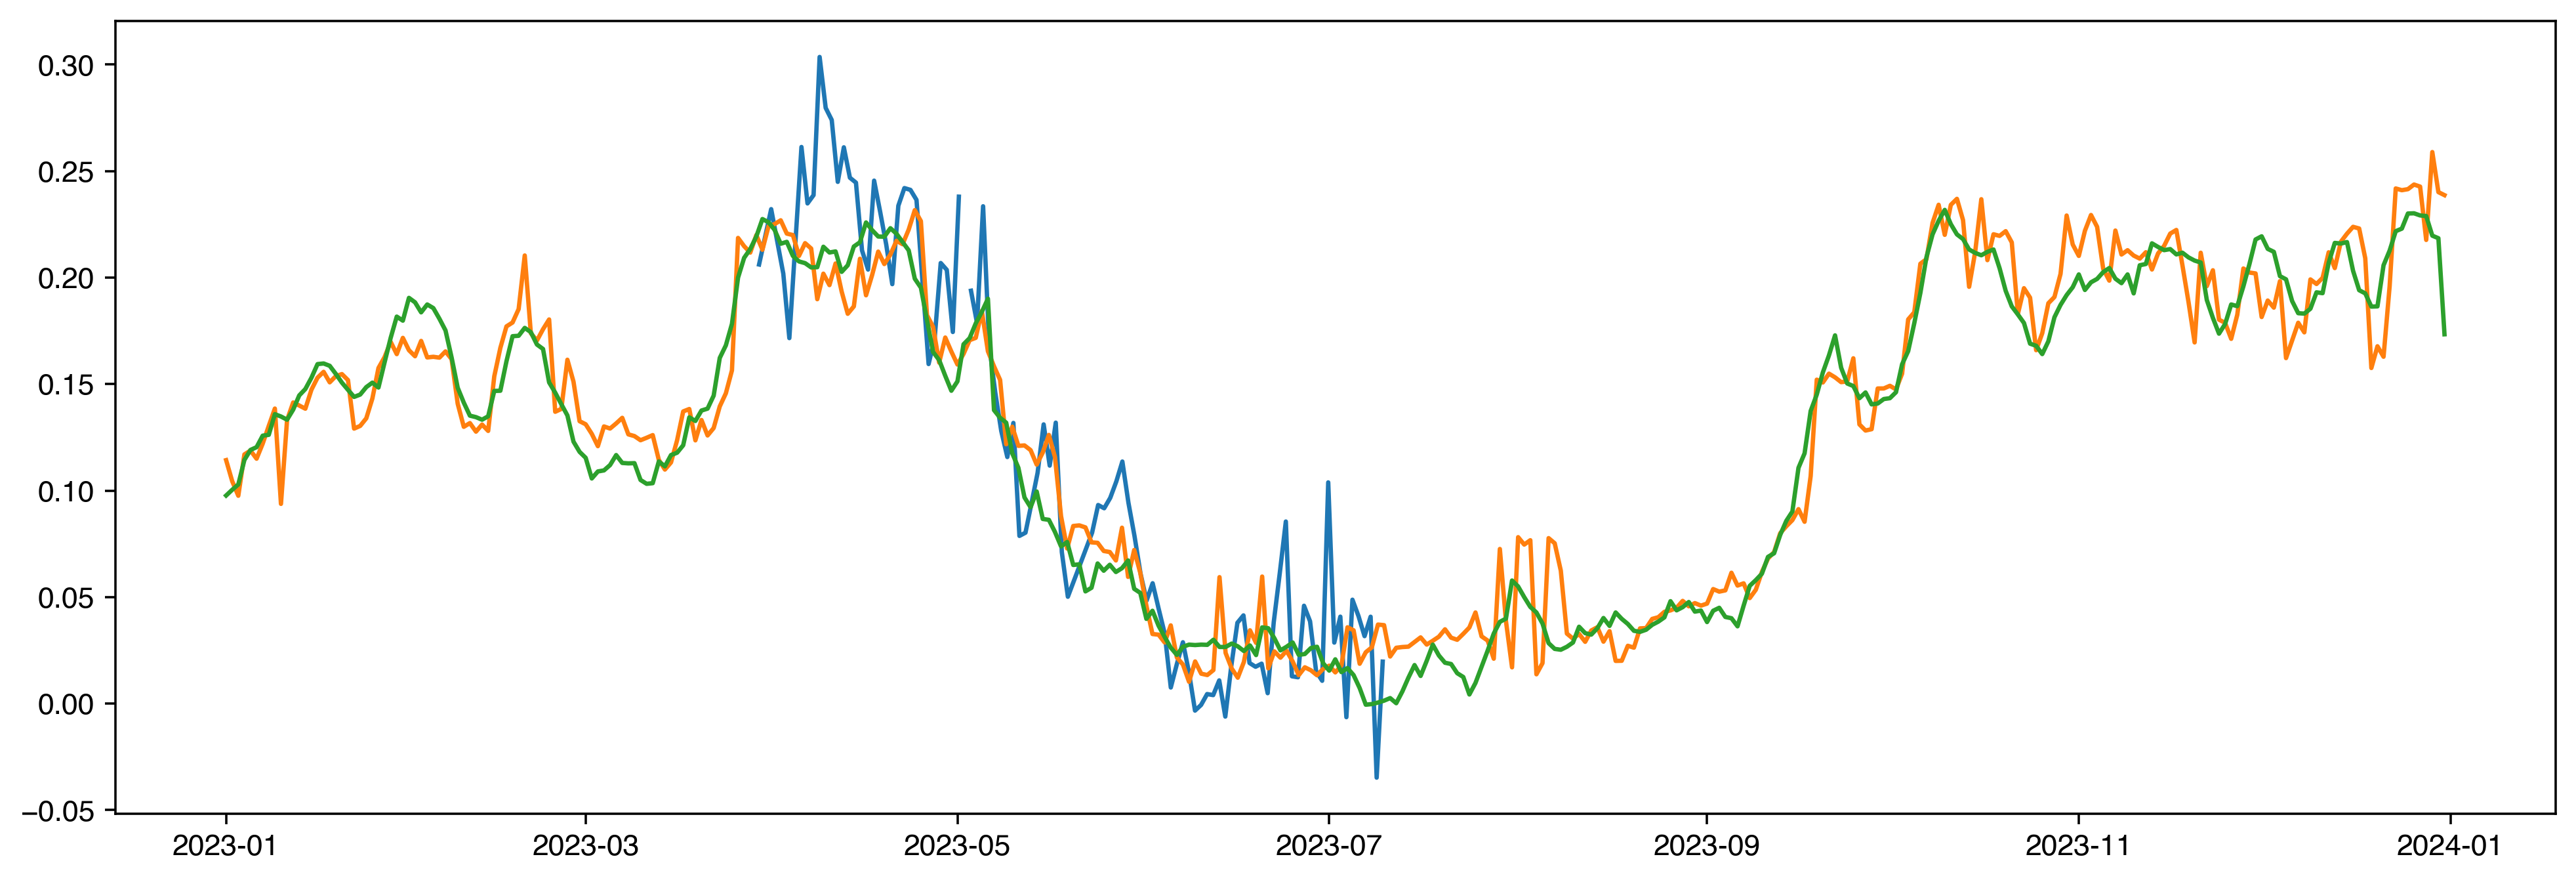

In [152]:
plt.figure(figsize=(15,5),dpi=320)

l = 0

plt.plot(nc.t,marcello.T[l])
plt.plot(lk.T.index[:-1],np.array(lk.T[l])[:-1])
plt.plot(df.T.index[:-1],np.array(df.T[l])[:-1])